In [60]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
import operator
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langgraph.checkpoint.memory import InMemorySaver 

In [61]:
load_dotenv()

True

In [74]:
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-2-7b-chat-hf",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

In [51]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [52]:
def get_joke(state: JokeState) -> JokeState:
    topic = state["topic"]
    prompt = (f"Tell me a humorous joke about {topic}")
    joke = model.invoke(prompt).content
    return {"joke": joke}

def get_explanation(state: JokeState) -> JokeState:
    joke = state["joke"]
    prompt = (f"Explain the following joke in a humorous way: {joke}")
    explanation = model.invoke(prompt).content
    return {"explanation": explanation}

In [53]:
graph = StateGraph(JokeState)
graph.add_node('get_joke', get_joke)
graph.add_node('add_explanation',get_explanation)

graph.add_edge(START, 'get_joke')
graph.add_edge('get_joke', 'add_explanation')
graph.add_edge('add_explanation', END)
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

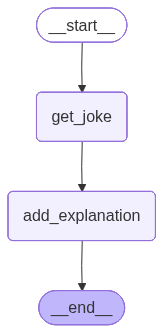

In [54]:
workflow

In [55]:
config1 = {"configurable": {"thread_id": "1"}}
config2 = {"configurable": {"thread_id": "2"}}

In [56]:
workflow.invoke({"topic": "programming"}, config=config1)

{'topic': 'programming',
 'joke': "Why was the programmer sad?\n\nBecause he didn't C# (see sharp) enough.",
 'explanation': 'Alright, gather \'round, you bunch of syntax-challenged individuals! Let\'s unpack this gem of a joke, which, let\'s be honest, is probably funnier if you\'ve ever stared blankly at a screen wondering why your code is behaving like a sentient toaster with a grudge.\n\nSo, the joke is: **Why was the programmer sad?**\n\nAnd the punchline is: **Because he didn\'t C# (see sharp) enough.**\n\nNow, for those of you who are more familiar with knitting patterns than binary code, let\'s break it down.\n\n**The Setup:** We have a programmer. Programmers, as a species, are often depicted as slightly melancholic. It\'s usually because their code *isn\'t* working, or because they\'ve just discovered a bug that will require them to rewrite half their project. It\'s a tough life, full of existential dread and the constant fear of a rogue semicolon.\n\n**The Punchline - The Do

In [57]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'programming', 'joke': "Why was the programmer sad?\n\nBecause he didn't C# (see sharp) enough.", 'explanation': 'Alright, gather \'round, you bunch of syntax-challenged individuals! Let\'s unpack this gem of a joke, which, let\'s be honest, is probably funnier if you\'ve ever stared blankly at a screen wondering why your code is behaving like a sentient toaster with a grudge.\n\nSo, the joke is: **Why was the programmer sad?**\n\nAnd the punchline is: **Because he didn\'t C# (see sharp) enough.**\n\nNow, for those of you who are more familiar with knitting patterns than binary code, let\'s break it down.\n\n**The Setup:** We have a programmer. Programmers, as a species, are often depicted as slightly melancholic. It\'s usually because their code *isn\'t* working, or because they\'ve just discovered a bug that will require them to rewrite half their project. It\'s a tough life, full of existential dread and the constant fear of a rogue semicolon.\n\n**The

In [58]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'programming', 'joke': "Why was the programmer sad?\n\nBecause he didn't C# (see sharp) enough.", 'explanation': 'Alright, gather \'round, you bunch of syntax-challenged individuals! Let\'s unpack this gem of a joke, which, let\'s be honest, is probably funnier if you\'ve ever stared blankly at a screen wondering why your code is behaving like a sentient toaster with a grudge.\n\nSo, the joke is: **Why was the programmer sad?**\n\nAnd the punchline is: **Because he didn\'t C# (see sharp) enough.**\n\nNow, for those of you who are more familiar with knitting patterns than binary code, let\'s break it down.\n\n**The Setup:** We have a programmer. Programmers, as a species, are often depicted as slightly melancholic. It\'s usually because their code *isn\'t* working, or because they\'ve just discovered a bug that will require them to rewrite half their project. It\'s a tough life, full of existential dread and the constant fear of a rogue semicolon.\n\n**Th

In [63]:
workflow.invoke({"topic": "Duck Duck Go"}, config=config2)

{'topic': 'Duck Duck Go',
 'joke': 'Why did the user switch from Google to DuckDuckGo?\n\nBecause they were tired of their search engine following them around like a stalker, and they preferred a search engine that just **quacked** under pressure!',
 'explanation': 'Here is an explanation of that joke, delivered with the appropriate level of comedic analysis:\n\n***\n\n**The Setup: The Digital Stalker**\nFirst, we have the "Google" part of the joke. The joke suggests that Google isn’t just a search engine; it’s a clingy ex-boyfriend. You search for "best air fryers" once, and suddenly every website you visit for the next three years is screaming, *"HEY! REMEMBER THE AIR FRYERS? I SAW YOU LOOKING AT THEM! BUY THE FRYERS!"* The joke is that switching to DuckDuckGo is basically the digital equivalent of changing your locks and getting a restraining order against your own browser history.\n\n**The Punchline: The "Quack" Attack**\nThen we hit the punchline, which is a classic **Double-Whamm

In [64]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Duck Duck Go', 'joke': 'Why did the user switch from Google to DuckDuckGo?\n\nBecause they were tired of their search engine following them around like a stalker, and they preferred a search engine that just **quacked** under pressure!', 'explanation': 'Here is an explanation of that joke, delivered with the appropriate level of comedic analysis:\n\n***\n\n**The Setup: The Digital Stalker**\nFirst, we have the "Google" part of the joke. The joke suggests that Google isn’t just a search engine; it’s a clingy ex-boyfriend. You search for "best air fryers" once, and suddenly every website you visit for the next three years is screaming, *"HEY! REMEMBER THE AIR FRYERS? I SAW YOU LOOKING AT THEM! BUY THE FRYERS!"* The joke is that switching to DuckDuckGo is basically the digital equivalent of changing your locks and getting a restraining order against your own browser history.\n\n**The Punchline: The "Quack" Attack**\nThen we hit the punchline, which is a cl

# State Updation 

In [65]:
config3 = {"configurable": {"thread_id": "2","checkpoint_id": "1f15fe68-33eb-60f4-8000-e81d7771a529","checkpoint_ns": ''}}

In [66]:
workflow.update_state(config3, {'topic':'Pringles'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f15fe86-1dd7-6290-8000-a82ff5e6405b'}}

In [67]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Pringles'}, next=('get_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f15fe86-1dd7-6290-8000-a82ff5e6405b'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-06-04T07:38:30.415004+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f15fe68-33eb-60f4-8000-e81d7771a529'}}, tasks=(PregelTask(id='9b017127-6210-10fa-8b3d-7d962e99c24b', name='get_joke', path=('__pregel_pull', 'get_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Duck Duck Go', 'joke': 'Why did the user switch from Google to DuckDuckGo?\n\nBecause they were tired of their search engine following them around like a stalker, and they preferred a search engine that just **quacked** under pressure!', 'explanation': 'Here is an explanation of that joke, delivered with the appropriate level of comedic analysis:\n\n***\n\n*

In [68]:
config4 = {"configurable": {"thread_id": "2","checkpoint_id": "1f15fe77-5961-6130-8001-ec36fc5d3375","checkpoint_ns": ''}}

In [70]:
workflow.invoke(None, config2)

{'topic': 'Pringles',
 'joke': 'Why did the Pringles can get promoted at work?\n\nBecause it was always **stacked** with great ideas!',
 'explanation': 'Here is the breakdown of this high-calorie comedy:\n\nFirst, we have to look at the **corporate logic** here. Most employees get promoted because of "synergy," "leverage," or "thought leadership." But the Pringles can? The Pringles can gets promoted because it’s literally built for one thing: **vertical integration.**\n\nNow, let\'s dissect the pun. In the business world, if you are **"stacked,"** it usually means you’re loaded with cash or have a resume that makes other people want to cry. But in the world of snack foods, "stacked" is just a Tuesday. \n\nPringles aren\'t like regular potato chips—those chaotic, jagged rebels that settle randomly in a bag like a pile of salty laundry. No, Pringles are *disciplined*. They are uniform. They are organized. They are a salty army marching in perfect formation.\n\nSo, the joke is basically s

In [71]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Pringles', 'joke': 'Why did the Pringles can get promoted at work?\n\nBecause it was always **stacked** with great ideas!', 'explanation': 'Here is the breakdown of this high-calorie comedy:\n\nFirst, we have to look at the **corporate logic** here. Most employees get promoted because of "synergy," "leverage," or "thought leadership." But the Pringles can? The Pringles can gets promoted because it’s literally built for one thing: **vertical integration.**\n\nNow, let\'s dissect the pun. In the business world, if you are **"stacked,"** it usually means you’re loaded with cash or have a resume that makes other people want to cry. But in the world of snack foods, "stacked" is just a Tuesday. \n\nPringles aren\'t like regular potato chips—those chaotic, jagged rebels that settle randomly in a bag like a pile of salty laundry. No, Pringles are *disciplined*. They are uniform. They are organized. They are a salty army marching in perfect formation.\n\nSo, the

# Time Travel

In [72]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f15fe7e-6364-6d42-8000-bf8de7f4c88f"}})

StateSnapshot(values={'topic': 'programming'}, next=('get_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f15fe7e-6364-6d42-8000-bf8de7f4c88f'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-04T07:35:02.959846+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15fe7e-6363-66b8-bfff-e7ec760d14b2'}}, tasks=(PregelTask(id='bd7a18e4-04ea-1fe6-7a4e-bb688c166532', name='get_joke', path=('__pregel_pull', 'get_joke'), error=None, interrupts=(), state=None, result={'joke': "Why was the programmer sad?\n\nBecause he didn't C# (see sharp) enough."}),), interrupts=())

In [75]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f15fe7e-6364-6d42-8000-bf8de7f4c88f"}})

BadRequestError: (Request ID: Root=1-6a212c30-6c9407bb7281b5c35b37a9a6;1759c69d-cf05-4a2b-b53f-1997898b87d5)

Bad request:
{'message': "The requested model 'meta-llama/Llama-2-7b-chat-hf' is not supported by any provider you have enabled.", 'type': 'invalid_request_error', 'param': 'model', 'code': 'model_not_supported'}